# 1.Cargar Librerias

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from IPython.display import Video, display



# 2. Descargar el dataset

In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pip install SoccerNet --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
import SoccerNet
import pkgutil
from SoccerNet.Downloader import SoccerNetDownloader
import configparser

[p.name for p in pkgutil.iter_modules(SoccerNet.__path__)]

['DataLoader', 'Downloader', 'utils']

In [ ]:
mySoccerNetDownloader=SoccerNetDownloader(LocalDirectory="/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data")

mySoccerNetDownloader.downloadDataTask(task="tracking-2023", split=["train", "test", "challenge"])

# 3. Descomprimir el dataset

In [ ]:
BASE = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet"
os.makedirs(BASE, exist_ok=True)


In [ ]:
!unzip -q "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/tracking-2023/train.zip" -d "{BASE}"



replace /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-060/gt/gt.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-060/det/det.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train/SNMOT-060/seqinfo.ini? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
!unzip -q "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/tracking-2023/test.zip" -d "{BASE}"


In [ ]:
!unzip -q "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/tracking-2023/challenge2023.zip" -d "{BASE}"


# 4. Visualizar ejemplo del dataset

Número de frames: 750
Primeros 5 frames: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


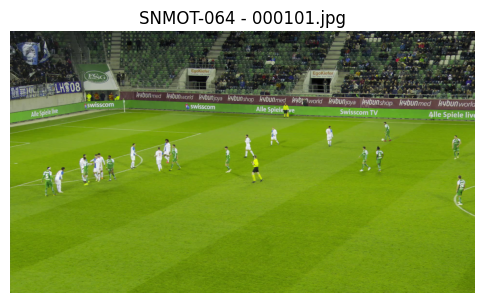

In [ ]:
#DATA_ROOT = "/kaggle/input/soccernet-tracking/train"

# Elegimos una secuencia
seq = "SNMOT-064"
img_dir = os.path.join(BASE,"train", seq, "img1")

# Listar frames
frames = sorted(os.listdir(img_dir))
print("Número de frames:", len(frames))
print("Primeros 5 frames:", frames[:5])

# Cargar un frame de ejemplo (por ejemplo el 100)
frame_name = frames[100]
img_path = os.path.join(img_dir, frame_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"{seq} - {frame_name}")
plt.axis("off")
plt.show()


In [ ]:
#Se lee la información de la seq para crear el video

seq_dir = os.path.join(BASE, "train", seq)  # ajusta la secuencia
seqinfo_path = os.path.join(seq_dir, "seqinfo.ini")

config = configparser.ConfigParser()
config.read(seqinfo_path)

seq_name = config["Sequence"]["name"]
fps = int(config["Sequence"]["frameRate"])
H = int(config["Sequence"]["imHeight"])
W = int(config["Sequence"]["imWidth"])
img_ext = config["Sequence"]["imExt"]


In [ ]:
img_dir = os.path.join(seq_dir, "img1")
frames = sorted(os.listdir(img_dir))

# Cantidad de frames a usar
N_FRAMES = min(250, len(frames))

out_path = f"/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/{seq_name}_preview.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

for fname in frames[:N_FRAMES]:
    frame_path = os.path.join(img_dir, fname)
    frame = cv2.imread(frame_path)

    if frame is None:
        continue

    # Aseguramos tamaño correcto
    frame = cv2.resize(frame, (W, H))

    video_writer.write(frame)

video_writer.release()

print("Video guardado en:", out_path)



Video guardado en: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/results/SNMOT-064_preview.mp4


In [ ]:
from IPython.display import HTML

HTML(f"""
<video width="640" height="360" controls>
  <source src="{out_path}" type="video/mp4">
  Tu navegador no soporta video HTML5.
</video>
""")
